In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install timm  # PyTorch Image Models - has pretrained ViT
!pip install einops  # For tensor operations in ViT
!pip install matplotlib seaborn scikit-learn pandas

# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from timm import create_model  # For pretrained ViT models

import pandas as pd
import numpy as np
from PIL import Image
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


In [ ]:
# Define base path
base_path = Path('/content/drive/MyDrive/BreaKHis_v1/histology_slides/breast')

# Check if path exists
print(f"Dataset exists: {base_path.exists()}")

# Explore structure
if base_path.exists():
    print("\nDataset structure:")
    for item in base_path.iterdir():
        print(f"  {item.name}")

    # Check benign folder structure
    benign_path = base_path / 'benign' / 'SOB'
    if benign_path.exists():
        print(f"\nBenign subtypes:")
        for subtype in benign_path.iterdir():
            if subtype.is_dir():
                print(f"  {subtype.name}")

Dataset exists: True

Dataset structure:
  README.txt
  count_files.sh
  .DS_Store
  benign
  malignant
  BreaKHis_metadata.csv

Benign subtypes:
  tubular_adenoma
  phyllodes_tumor
  adenosis
  fibroadenoma


In [ ]:
# Load metadata
metadata_path = base_path / 'BreaKHis_metadata.csv'
metadata = pd.read_csv(metadata_path)

print("Metadata shape:", metadata.shape)
print("\nFirst few rows:")
print(metadata.head())
print("\nColumn names:")
print(metadata.columns.tolist())
print("\nClass distribution:")
print(metadata['tumor_class'].value_counts() if 'tumor_class' in metadata.columns else "Need to check column names")

Metadata shape: (7898, 6)

First few rows:
                                            filepath tumor_type subtype  \
0  /content/drive/MyDrive/BreaKHis_v1/histology_s...          b      ta   
1  /content/drive/MyDrive/BreaKHis_v1/histology_s...          b      ta   
2  /content/drive/MyDrive/BreaKHis_v1/histology_s...          b      ta   
3  /content/drive/MyDrive/BreaKHis_v1/histology_s...          b      ta   
4  /content/drive/MyDrive/BreaKHis_v1/histology_s...          b      ta   

   magnification  subject_id partition  
0            100  14-16184CD     train  
1            100  14-16184CD     train  
2            100  14-16184CD     train  
3            100  14-16184CD     train  
4            100  14-16184CD     train  

Column names:
['filepath', 'tumor_type', 'subtype', 'magnification', 'subject_id', 'partition']

Class distribution:
Need to check column names


In [ ]:
# Check tumor type distribution
print("Tumor type distribution:")
print(metadata['tumor_type'].value_counts())
print("\nSubtype distribution:")
print(metadata['subtype'].value_counts())
print("\nMagnification distribution:")
print(metadata['magnification'].value_counts())
print("\nPartition distribution:")
print(metadata['partition'].value_counts())
print("\nNumber of unique subjects:")
print(metadata['subject_id'].nunique())

# Check if files exist (sample a few)
sample_paths = metadata['filepath'].head(3).tolist()
for path in sample_paths:
    print(f"File exists: {os.path.exists(path)} - {path}")

Tumor type distribution:
tumor_type
m    5418
b    2480
Name: count, dtype: int64

Subtype distribution:
subtype
dc    3441
f     1014
mc     791
lc     626
ta     569
pc     560
pt     453
a      444
Name: count, dtype: int64

Magnification distribution:
magnification
100    2076
200    2013
40     1991
400    1818
Name: count, dtype: int64

Partition distribution:
partition
train    6308
val      1590
Name: count, dtype: int64

Number of unique subjects:
81
File exists: True - /content/drive/MyDrive/BreaKHis_v1/histology_slides/breast/benign/SOB/tubular_adenoma/SOB_B_TA_14-16184CD/100X/SOB_B_TA-14-16184CD-100-004.png
File exists: True - /content/drive/MyDrive/BreaKHis_v1/histology_slides/breast/benign/SOB/tubular_adenoma/SOB_B_TA_14-16184CD/100X/SOB_B_TA-14-16184CD-100-025.png
File exists: True - /content/drive/MyDrive/BreaKHis_v1/histology_slides/breast/benign/SOB/tubular_adenoma/SOB_B_TA_14-16184CD/100X/SOB_B_TA-14-16184CD-100-016.png


In [ ]:
class BreaKHisDataset(Dataset):
    """
    BreaKHis Dataset with magnification awareness
    """
    def __init__(self, metadata_df, transform=None, return_magnification=True):
        """
        Args:
            metadata_df: Pandas DataFrame with columns [filepath, tumor_type, subtype, magnification, subject_id]
            transform: torchvision transforms
            return_magnification: Whether to return magnification as a feature
        """
        self.metadata = metadata_df.reset_index(drop=True)
        self.transform = transform
        self.return_magnification = return_magnification

        # Create label mappings
        # Binary: b=0 (benign), m=1 (malignant)
        self.tumor_type_map = {'b': 0, 'm': 1}

        # Subtype: 8 classes (4 benign + 4 malignant)
        # Benign: adenosis(a), fibroadenoma(f), phyllodes_tumor(pt), tubular_adenoma(ta)
        # Malignant: ductal_carcinoma(dc), lobular_carcinoma(lc), mucinous_carcinoma(mc), papillary_carcinoma(pc)
        self.subtype_map = {
            'a': 0, 'f': 1, 'pt': 2, 'ta': 3,  # benign
            'dc': 4, 'lc': 5, 'mc': 6, 'pc': 7  # malignant
        }

        # Magnification encoding: 40x=0, 100x=1, 200x=2, 400x=3
        self.mag_map = {40: 0, 100: 1, 200: 2, 400: 3}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Get metadata
        row = self.metadata.iloc[idx]
        img_path = row['filepath']

        # Load image (SILENTLY handle errors)
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Silently return black image as fallback (NO PRINT)
            image = Image.new('RGB', (224, 224), color='black')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Get labels
        binary_label = self.tumor_type_map[row['tumor_type']]
        subtype_label = self.subtype_map[row['subtype']]
        mag_level = self.mag_map[row['magnification']]

        output = {
            'image': image,
            'binary_label': torch.tensor(binary_label, dtype=torch.long),
            'subtype_label': torch.tensor(subtype_label, dtype=torch.long),
            'magnification': torch.tensor(mag_level, dtype=torch.long),
            'subject_id': row['subject_id']
        }

        return output

print("✓ Updated Dataset class defined (silent mode)")

✓ Updated Dataset class defined (silent mode)


In [ ]:
# Define transforms (matching report's preprocessing)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT standard input size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("✓ Transforms defined")

✓ Transforms defined


In [ ]:
# Split data by partition (already split in metadata)
train_metadata = metadata[metadata['partition'] == 'train'].copy()
val_metadata = metadata[metadata['partition'] == 'val'].copy()

print(f"Train samples: {len(train_metadata)}")
print(f"Val samples: {len(val_metadata)}")

# Check subject-level split (no leakage)
train_subjects = set(train_metadata['subject_id'].unique())
val_subjects = set(val_metadata['subject_id'].unique())

print(f"\nSubject overlap check:")
print(f"Train-Val overlap: {len(train_subjects & val_subjects)} (should be 0)")
print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(val_subjects)}")

# Create datasets
train_dataset = BreaKHisDataset(train_metadata, transform=train_transform)
val_dataset = BreaKHisDataset(val_metadata, transform=val_transform)

# Create dataloaders
batch_size = 32  # Adjust based on your memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✓ Dataloaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# Test loading one batch
print("\nTesting batch loading...")
test_batch = next(iter(train_loader))
print(f"✓ Test batch shapes:")
print(f"    Image: {test_batch['image'].shape}")
print(f"    Binary label: {test_batch['binary_label'].shape}")
print(f"    Subtype label: {test_batch['subtype_label'].shape}")
print(f"    Magnification: {test_batch['magnification'].shape}")

Train samples: 6308
Val samples: 1590

Subject overlap check:
Train-Val overlap: 0 (should be 0)
Train subjects: 64
Val subjects: 17

✓ Dataloaders created:
  Train batches: 198
  Val batches: 50

Testing batch loading...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✓ Test batch shapes:
    Image: torch.Size([32, 3, 224, 224])
    Binary label: torch.Size([32])
    Subtype label: torch.Size([32])
    Magnification: torch.Size([32])


In [ ]:
# Silence corrupted image warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress PIL errors specifically
import logging
logging.getLogger('PIL').setLevel(logging.ERROR)

In [ ]:
class ViT_BreaKHis(nn.Module):
    """
    Vision Transformer for BreaKHis with magnification token embedding
    Matches your ResNet baseline's multimodal fusion approach
    """
    def __init__(
        self,
        model_name='vit_small_patch16_224',  # Options: vit_tiny, vit_small, vit_base
        pretrained=True,
        num_classes_binary=2,
        num_classes_subtype=8,
        num_magnifications=4,
        dropout=0.2
    ):
        super(ViT_BreaKHis, self).__init__()

        # Load pretrained ViT encoder
        self.vit_encoder = create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,  # Remove classification head
            global_pool='token'  # Use CLS token pooling
        )

        # Get embedding dimension from the model
        # vit_tiny: 192, vit_small: 384, vit_base: 768
        if 'tiny' in model_name:
            self.embed_dim = 192
        elif 'small' in model_name:
            self.embed_dim = 384
        elif 'base' in model_name:
            self.embed_dim = 768
        else:
            self.embed_dim = 384  # default

        print(f"Using {model_name} with embedding dimension: {self.embed_dim}")

        # Magnification token embedding (learnable)
        self.magnification_embedding = nn.Embedding(
            num_embeddings=num_magnifications,  # 4 magnifications
            embedding_dim=self.embed_dim
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Binary classification head (benign vs malignant)
        self.binary_head = nn.Sequential(
            nn.Linear(self.embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes_binary)
        )

        # Subtype classification head (8-way)
        self.subtype_head = nn.Sequential(
            nn.Linear(self.embed_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes_subtype)
        )

    def forward(self, image, magnification):
        """
        Args:
            image: [batch_size, 3, 224, 224]
            magnification: [batch_size] - magnification level (0, 1, 2, or 3)

        Returns:
            binary_logits: [batch_size, 2]
            subtype_logits: [batch_size, 8]
        """
        # Extract image features with ViT
        image_features = self.vit_encoder(image)  # [batch_size, embed_dim]

        # Get magnification token
        mag_token = self.magnification_embedding(magnification)  # [batch_size, embed_dim]

        # Fuse image and magnification (additive, matching your ResNet baseline)
        fused_features = image_features + mag_token  # [batch_size, embed_dim]
        fused_features = self.dropout(fused_features)

        # Predict binary and subtype
        binary_logits = self.binary_head(fused_features)
        subtype_logits = self.subtype_head(fused_features)

        return binary_logits, subtype_logits

# Initialize model
model = ViT_BreaKHis(
    model_name='vit_small_patch16_224',  # Start with small (22M params)
    pretrained=True,
    dropout=0.2
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model initialized")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
test_batch = next(iter(train_loader))
test_images = test_batch['image'].to(device)# Silence corrupted image warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress PIL errors specifically
import logging
logging.getLogger('PIL').setLevel(logging.ERROR)
test_mags = test_batch['magnification'].to(device)

with torch.no_grad():
    binary_out, subtype_out = model(test_images, test_mags)
    print(f"\n✓ Forward pass test:")
    print(f"  Binary output: {binary_out.shape}")
    print(f"  Subtype output: {subtype_out.shape}")

Using vit_small_patch16_224 with embedding dimension: 384

✓ Model initialized
  Total parameters: 21,967,498
  Trainable parameters: 21,967,498

✓ Forward pass test:
  Binary output: torch.Size([32, 2])
  Subtype output: torch.Size([32, 8])


In [ ]:
class MultiTaskLoss(nn.Module):
    """
    Multi-task loss: Binary + Masked Subtype Classification
    Matches your report's approach
    """
    def __init__(self, lambda_subtype=1.0):
        super(MultiTaskLoss, self).__init__()
        self.lambda_subtype = lambda_subtype
        self.binary_loss_fn = nn.CrossEntropyLoss()
        self.subtype_loss_fn = nn.CrossEntropyLoss(reduction='none')  # No reduction for masking

    def forward(self, binary_logits, subtype_logits, binary_labels, subtype_labels):
        """
        Args:
            binary_logits: [batch, 2]
            subtype_logits: [batch, 8]
            binary_labels: [batch] - 0 for benign, 1 for malignant
            subtype_labels: [batch] - 0-3 for benign, 4-7 for malignant
        """
        # Binary loss (always computed)
        loss_binary = self.binary_loss_fn(binary_logits, binary_labels)

        # Subtype loss (only for valid semantic classes)
        # Create mask: benign samples (label 0) can only be subtypes 0-3
        #              malignant samples (label 1) can only be subtypes 4-7
        subtype_loss_per_sample = self.subtype_loss_fn(subtype_logits, subtype_labels)

        # Apply masking: compute loss only for semantically valid predictions
        # For benign (binary_label=0): subtype should be 0-3
        # For malignant (binary_label=1): subtype should be 4-7
        benign_mask = (binary_labels == 0) & (subtype_labels < 4)
        malignant_mask = (binary_labels == 1) & (subtype_labels >= 4)
        valid_mask = benign_mask | malignant_mask

        # Compute masked subtype loss
        if valid_mask.sum() > 0:
            loss_subtype = subtype_loss_per_sample[valid_mask].mean()
        else:
            loss_subtype = torch.tensor(0.0, device=binary_logits.device)

        # Total loss
        total_loss = loss_binary + self.lambda_subtype * loss_subtype

        return total_loss, loss_binary, loss_subtype

# Initialize loss
criterion = MultiTaskLoss(lambda_subtype=1.0)
print("✓ Loss function defined")

✓ Loss function defined


In [ ]:
# Optimizer - AdamW with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,  # Start conservative since we're fine-tuning pretrained ViT
    weight_decay=0.01
)

# Learning rate scheduler - Cosine annealing with warmup
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

# Warmup for first 5 epochs
warmup_epochs = 5
total_epochs = 30

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_epochs
)

# Cosine annealing after warmup
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=total_epochs - warmup_epochs,
    eta_min=1e-6
)

# Combine schedulers
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

print("✓ Optimizer and scheduler initialized")
print(f"  Optimizer: AdamW (lr={1e-4}, weight_decay={0.01})")
print(f"  Scheduler: Warmup ({warmup_epochs} epochs) + Cosine Annealing")

✓ Optimizer and scheduler initialized
  Optimizer: AdamW (lr=0.0001, weight_decay=0.01)
  Scheduler: Warmup (5 epochs) + Cosine Annealing


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
import time

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()

    running_loss = 0.0
    running_binary_loss = 0.0
    running_subtype_loss = 0.0

    all_binary_preds = []
    all_binary_labels = []
    all_binary_probs = []

    all_subtype_preds = []
    all_subtype_labels = []

    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1} [Train]')

    for batch_idx, batch in enumerate(progress_bar):
        # Move data to device
        images = batch['image'].to(device)
        mags = batch['magnification'].to(device)
        binary_labels = batch['binary_label'].to(device)
        subtype_labels = batch['subtype_label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        binary_logits, subtype_logits = model(images, mags)

        # Compute loss
        total_loss, binary_loss, subtype_loss = criterion(
            binary_logits, subtype_logits, binary_labels, subtype_labels
        )

        # Backward pass
        total_loss.backward()
        optimizer.step()

        # Track losses
        running_loss += total_loss.item()
        running_binary_loss += binary_loss.item()
        running_subtype_loss += subtype_loss.item()

        # Get predictions
        binary_probs = F.softmax(binary_logits, dim=1)[:, 1].detach().cpu().numpy()
        binary_preds = binary_logits.argmax(dim=1).detach().cpu().numpy()
        subtype_preds = subtype_logits.argmax(dim=1).detach().cpu().numpy()

        all_binary_preds.extend(binary_preds)
        all_binary_labels.extend(binary_labels.cpu().numpy())
        all_binary_probs.extend(binary_probs)
        all_subtype_preds.extend(subtype_preds)
        all_subtype_labels.extend(subtype_labels.cpu().numpy())

        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'bin_loss': f'{binary_loss.item():.4f}',
            'sub_loss': f'{subtype_loss.item():.4f}'
        })

    # Calculate metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_binary_loss = running_binary_loss / len(dataloader)
    epoch_subtype_loss = running_subtype_loss / len(dataloader)

    binary_acc = accuracy_score(all_binary_labels, all_binary_preds)
    binary_auc = roc_auc_score(all_binary_labels, all_binary_probs)
    subtype_acc = accuracy_score(all_subtype_labels, all_subtype_preds)

    return {
        'loss': epoch_loss,
        'binary_loss': epoch_binary_loss,
        'subtype_loss': epoch_subtype_loss,
        'binary_acc': binary_acc,
        'binary_auc': binary_auc,
        'subtype_acc': subtype_acc
    }


def validate(model, dataloader, criterion, device, epoch):
    """Validate the model"""
    model.eval()

    running_loss = 0.0
    running_binary_loss = 0.0
    running_subtype_loss = 0.0

    all_binary_preds = []
    all_binary_labels = []
    all_binary_probs = []

    all_subtype_preds = []
    all_subtype_labels = []

    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1} [Val]')

    with torch.no_grad():
        for batch in progress_bar:
            # Move data to device
            images = batch['image'].to(device)
            mags = batch['magnification'].to(device)
            binary_labels = batch['binary_label'].to(device)
            subtype_labels = batch['subtype_label'].to(device)

            # Forward pass
            binary_logits, subtype_logits = model(images, mags)

            # Compute loss
            total_loss, binary_loss, subtype_loss = criterion(
                binary_logits, subtype_logits, binary_labels, subtype_labels
            )

            # Track losses
            running_loss += total_loss.item()
            running_binary_loss += binary_loss.item()
            running_subtype_loss += subtype_loss.item()

            # Get predictions
            binary_probs = F.softmax(binary_logits, dim=1)[:, 1].cpu().numpy()
            binary_preds = binary_logits.argmax(dim=1).cpu().numpy()
            subtype_preds = subtype_logits.argmax(dim=1).cpu().numpy()

            all_binary_preds.extend(binary_preds)
            all_binary_labels.extend(binary_labels.cpu().numpy())
            all_binary_probs.extend(binary_probs)
            all_subtype_preds.extend(subtype_preds)
            all_subtype_labels.extend(subtype_labels.cpu().numpy())

            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{total_loss.item():.4f}'
            })

    # Calculate metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_binary_loss = running_binary_loss / len(dataloader)
    epoch_subtype_loss = running_subtype_loss / len(dataloader)

    binary_acc = accuracy_score(all_binary_labels, all_binary_preds)
    binary_auc = roc_auc_score(all_binary_labels, all_binary_probs)
    subtype_acc = accuracy_score(all_subtype_labels, all_subtype_preds)

    # Confusion matrix for binary classification
    cm_binary = confusion_matrix(all_binary_labels, all_binary_preds)

    return {
        'loss': epoch_loss,
        'binary_loss': epoch_binary_loss,
        'subtype_loss': epoch_subtype_loss,
        'binary_acc': binary_acc,
        'binary_auc': binary_auc,
        'subtype_acc': subtype_acc,
        'confusion_matrix': cm_binary,
        'all_binary_labels': all_binary_labels,
        'all_binary_probs': all_binary_probs,
        'all_subtype_labels': all_subtype_labels,
        'all_subtype_preds': all_subtype_preds
    }

print("✓ Training and validation functions defined")

✓ Training and validation functions defined


In [ ]:
# Training configuration
num_epochs = 10
best_val_auc = 0.0
best_model_path = '/content/drive/MyDrive/vit_breakhis_best.pth'

# Track history
history = {
    'train_loss': [], 'train_binary_acc': [], 'train_binary_auc': [], 'train_subtype_acc': [],
    'val_loss': [], 'val_binary_acc': [], 'val_binary_auc': [], 'val_subtype_acc': []
}

print("="*60)
print("Starting Training")
print("="*60)
print(f"Model: ViT-Small with {total_params:,} parameters")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print("="*60)

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    # Train
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)

    # Validate
    val_metrics = validate(model, val_loader, criterion, device, epoch)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_metrics['loss'])
    history['train_binary_acc'].append(train_metrics['binary_acc'])
    history['train_binary_auc'].append(train_metrics['binary_auc'])
    history['train_subtype_acc'].append(train_metrics['subtype_acc'])

    history['val_loss'].append(val_metrics['loss'])
    history['val_binary_acc'].append(val_metrics['binary_acc'])
    history['val_binary_auc'].append(val_metrics['binary_auc'])
    history['val_subtype_acc'].append(val_metrics['subtype_acc'])

    # Print epoch summary
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{num_epochs} - {epoch_time:.1f}s - LR: {current_lr:.2e}")
    print(f"  Train - Loss: {train_metrics['loss']:.4f} | Binary Acc: {train_metrics['binary_acc']:.4f} | Binary AUC: {train_metrics['binary_auc']:.4f} | Subtype Acc: {train_metrics['subtype_acc']:.4f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f} | Binary Acc: {val_metrics['binary_acc']:.4f} | Binary AUC: {val_metrics['binary_auc']:.4f} | Subtype Acc: {val_metrics['subtype_acc']:.4f}")
    print(f"  Val Confusion Matrix:\n{val_metrics['confusion_matrix']}")

    # Save best model
    if val_metrics['binary_auc'] > best_val_auc:
        best_val_auc = val_metrics['binary_auc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_auc': best_val_auc,
            'val_acc': val_metrics['binary_acc'],
            'history': history
        }, best_model_path)
        print(f"  ✓ Best model saved! (AUC: {best_val_auc:.4f})")

    print("-"*60)

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"Training Complete! Total time: {total_time/60:.1f} minutes")
print(f"Best Validation AUC: {best_val_auc:.4f}")
print(f"{'='*60}")

Starting Training
Model: ViT-Small with 21,967,498 parameters
Train samples: 6308
Val samples: 1590
Epochs: 30
Batch size: 32


Epoch 1 [Val]: 100%|██████████| 50/50 [03:21<00:00,  4.03s/it, loss=2.6044]



Epoch 1/30 - 2543.2s - LR: 2.80e-05
  Train - Loss: 1.4239 | Binary Acc: 0.9683 | Binary AUC: 0.9591 | Subtype Acc: 0.5774
  Val   - Loss: 1.7585 | Binary Acc: 0.9459 | Binary AUC: 0.9241 | Subtype Acc: 0.4409
  Val Confusion Matrix:
[[ 468   64]
 [  22 1036]]
  ✓ Best model saved! (AUC: 0.9241)
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 50/50 [03:21<00:00,  4.04s/it, loss=2.8132]



Epoch 2/30 - 2565.3s - LR: 4.60e-05
  Train - Loss: 1.1700 | Binary Acc: 0.9759 | Binary AUC: 0.9591 | Subtype Acc: 0.6658
  Val   - Loss: 1.7633 | Binary Acc: 0.9459 | Binary AUC: 0.9255 | Subtype Acc: 0.4774
  Val Confusion Matrix:
[[ 468   64]
 [  22 1036]]
  ✓ Best model saved! (AUC: 0.9255)
------------------------------------------------------------


...


Epoch 9/30 - 2568.9s - LR: 9.39e-05
  Train - Loss: 0.9647 | Binary Acc: 0.9757 | Binary AUC: 0.9639 | Subtype Acc: 0.7302
  Val   - Loss: 2.2293 | Binary Acc: 0.9459 | Binary AUC: 0.9311 | Subtype Acc: 0.4673
  Val Confusion Matrix:
[[ 468   64]
 [  22 1036]]
------------------------------------------------------------


Epoch 10 [Val]: 100%|██████████| 50/50 [03:24<00:00,  4.09s/it, loss=4.3389]



Epoch 10/30 - 2612.2s - LR: 9.05e-05
  Train - Loss: 0.9581 | Binary Acc: 0.9756 | Binary AUC: 0.9621 | Subtype Acc: 0.7315
  Val   - Loss: 2.1274 | Binary Acc: 0.9459 | Binary AUC: 0.9311 | Subtype Acc: 0.4717
  Val Confusion Matrix:
[[ 468   64]
 [  22 1036]]
------------------------------------------------------------


Epoch 11 [Train]:  10%|▉         | 19/198 [03:57<37:16, 12.49s/it, loss=0.8875, bin_loss=0.0269, sub_loss=0.8606]


KeyboardInterrupt: 

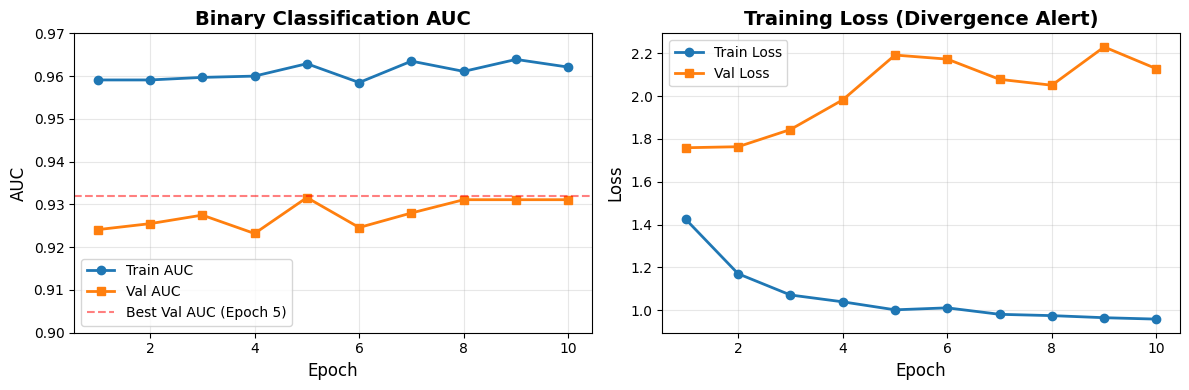

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your data from the logs
epochs = np.arange(1, 11)
train_auc = [0.9591, 0.9591, 0.9597, 0.9600, 0.9629, 0.9585, 0.9635, 0.9611, 0.9639, 0.9621]
val_auc = [0.9241, 0.9255, 0.9275, 0.9232, 0.9316, 0.9246, 0.9280, 0.9311, 0.9311, 0.9311]
train_loss = [1.4239, 1.1700, 1.0708, 1.0389, 1.0015, 1.0107, 0.9805, 0.9744, 0.9647, 0.9581]
val_loss = [1.7585, 1.7633, 1.8435, 1.9820, 2.1914, 2.1724, 2.0780, 2.0505, 2.2293, 2.1274]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# AUC plot
ax1.plot(epochs, train_auc, 'o-', label='Train AUC', linewidth=2)
ax1.plot(epochs, val_auc, 's-', label='Val AUC', linewidth=2)
ax1.axhline(y=0.932, color='r', linestyle='--', alpha=0.5, label='Best Val AUC (Epoch 5)')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_title('Binary Classification AUC', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0.90, 0.97])

# Loss plot
ax2.plot(epochs, train_loss, 'o-', label='Train Loss', linewidth=2)
ax2.plot(epochs, val_loss, 's-', label='Val Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training Loss (Divergence Alert)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

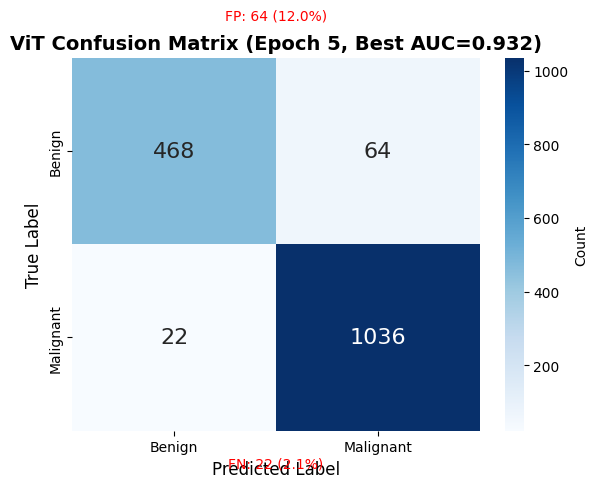

In [ ]:
import seaborn as sns

# From your epoch 5 results (best model)
confusion = np.array([[468, 64],
                      [22, 1036]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('ViT Confusion Matrix (Epoch 5, Best AUC=0.932)', fontsize=14, fontweight='bold')

# Add FN/FP annotations
ax.text(0.5, 1.1, 'FP: 64 (12.0%)', transform=ax.transAxes,
        fontsize=10, color='red', ha='center')
ax.text(0.5, -0.1, 'FN: 22 (2.1%)', transform=ax.transAxes,
        fontsize=10, color='red', ha='center')

plt.tight_layout()
plt.savefig('vit_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

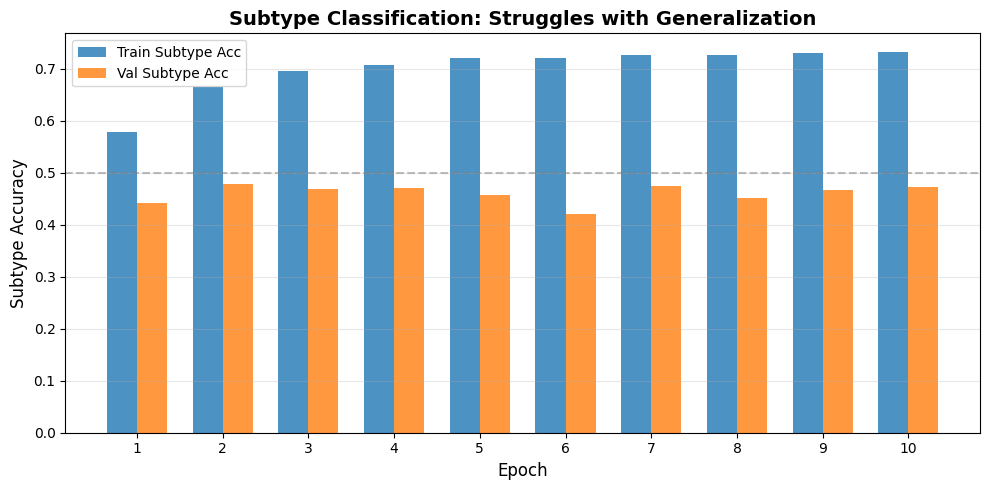

In [ ]:
# Subtype accuracy progression
epochs = np.arange(1, 11)
train_sub_acc = [0.5774, 0.6658, 0.6950, 0.7075, 0.7210, 0.7199, 0.7269, 0.7265, 0.7302, 0.7315]
val_sub_acc = [0.4409, 0.4774, 0.4686, 0.4698, 0.4572, 0.4208, 0.4742, 0.4516, 0.4673, 0.4717]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(epochs))
width = 0.35

ax.bar(x - width/2, train_sub_acc, width, label='Train Subtype Acc', alpha=0.8)
ax.bar(x + width/2, val_sub_acc, width, label='Val Subtype Acc', alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Subtype Accuracy', fontsize=12)
ax.set_title('Subtype Classification: Struggles with Generalization', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (8 classes)')

plt.tight_layout()
plt.savefig('vit_subtype_performance.png', dpi=300, bbox_inches='tight')
plt.show()

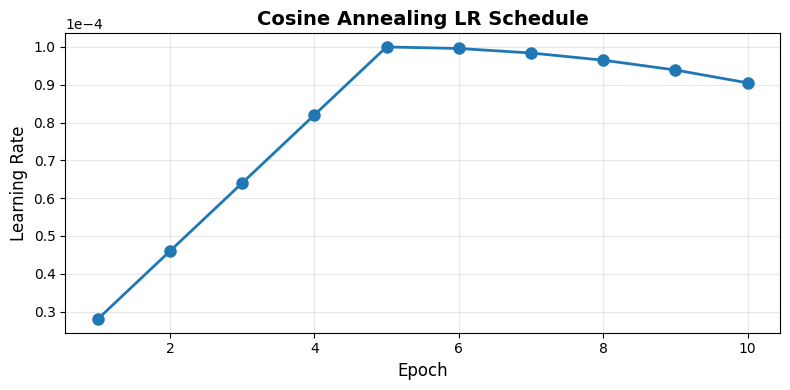

In [ ]:
# Your LR values from logs
epochs = np.arange(1, 11)
lr = [2.80e-05, 4.60e-05, 6.40e-05, 8.20e-05, 1.00e-04,
      9.96e-05, 9.84e-05, 9.65e-05, 9.39e-05, 9.05e-05]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, lr, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Cosine Annealing LR Schedule', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('vit_lr_schedule.png', dpi=300, bbox_inches='tight')
plt.show()

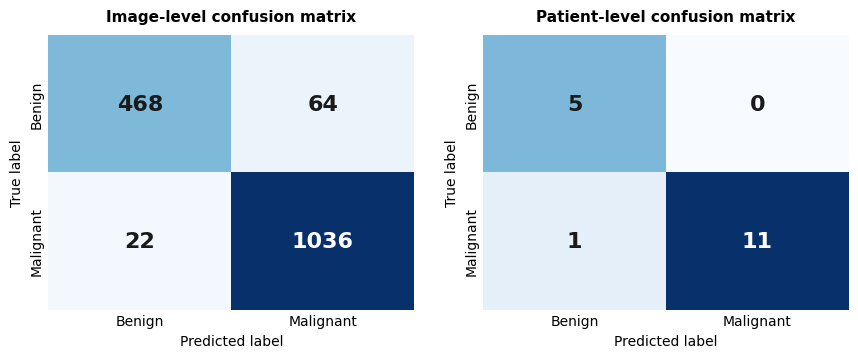

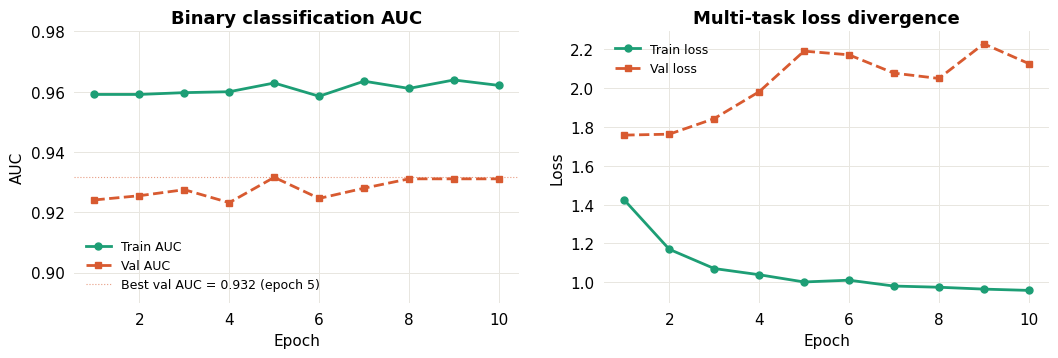

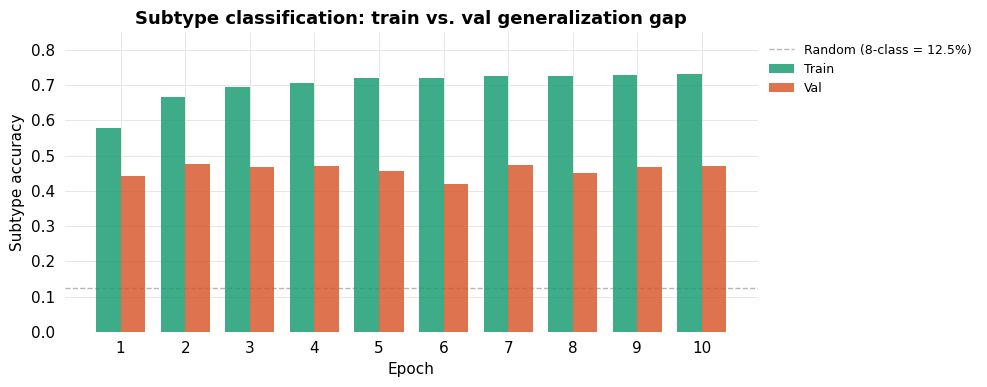

Saved: vit_cm.png | vit_curves.png | vit_subtype.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.colors import Normalize

plt.rcParams.update({"axes.grid": False})

epochs     = np.arange(1, 11)
train_auc  = [0.9591,0.9591,0.9597,0.9600,0.9629,0.9585,0.9635,0.9611,0.9639,0.9621]
val_auc    = [0.9241,0.9255,0.9275,0.9232,0.9316,0.9246,0.9280,0.9311,0.9311,0.9311]
train_loss = [1.4239,1.1700,1.0708,1.0389,1.0015,1.0107,0.9805,0.9744,0.9647,0.9581]
val_loss   = [1.7585,1.7633,1.8435,1.9820,2.1914,2.1724,2.0780,2.0505,2.2293,2.1274]
train_sub  = [0.5774,0.6658,0.6950,0.7075,0.7210,0.7199,0.7269,0.7265,0.7302,0.7315]
val_sub    = [0.4409,0.4774,0.4686,0.4698,0.4572,0.4208,0.4742,0.4516,0.4673,0.4717]

cm_img = np.array([[468,  64], [ 22, 1036]])
cm_pat = np.array([[5,  0], [1, 11]])

def plot_cm(ax, cm, title):
    cmap = plt.get_cmap("Blues")
    norm = Normalize(vmin=0, vmax=cm.max())
    labels = ["Benign", "Malignant"]
    ax.set_facecolor("white")
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            rect = patches.Rectangle(
                [j, 1-i], 1, 1,
                linewidth=0, edgecolor='none',
                facecolor=cmap(norm(cm[i, j]))
            )
            ax.add_patch(rect)
            tc = "white" if cm[i,j] > cm.max()*0.55 else "#1a1a1a"
            ax.text(j+0.5, 1-i+0.5, str(cm[i,j]),
                    ha="center", va="center",
                    fontsize=16, fontweight="bold", color=tc)
    ax.set_xlim(0,2); ax.set_ylim(0,2)
    ax.set_xticks([0.5,1.5]); ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([0.5,1.5]); ax.set_yticklabels(labels[::-1], fontsize=10,
                                                   rotation=90, va="center")
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

# fig:vit_cm
fig, axes = plt.subplots(1, 2, figsize=(9, 4), facecolor="white")
plot_cm(axes[0], cm_img, "Image-level confusion matrix")
plot_cm(axes[1], cm_pat, "Patient-level confusion matrix")
plt.tight_layout(pad=2)
plt.savefig("vit_cm.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# fig:vit_curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), facecolor="white")
for ax in [ax1, ax2]:
    ax.set_facecolor("white")
    ax.grid(True, color="#E8E6E0", linewidth=0.7, zorder=0)
    ax.spines[["top","right"]].set_visible(False)

ax1.plot(epochs, train_auc, "o-",  color="#1D9E75", lw=2, ms=5, label="Train AUC", zorder=3)
ax1.plot(epochs, val_auc,   "s--", color="#D85A30", lw=2, ms=5, label="Val AUC", zorder=3)
ax1.axhline(max(val_auc), color="#D85A30", lw=0.8, ls=":", alpha=0.6,
            label=f"Best val AUC = {max(val_auc):.3f} (epoch 5)", zorder=2)
ax1.set_ylim(0.89, 0.98)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("AUC")
ax1.set_title("Binary classification AUC", fontweight="bold")
ax1.legend(fontsize=9, frameon=False)

ax2.plot(epochs, train_loss, "o-",  color="#1D9E75", lw=2, ms=5, label="Train loss", zorder=3)
ax2.plot(epochs, val_loss,   "s--", color="#D85A30", lw=2, ms=5, label="Val loss", zorder=3)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Multi-task loss divergence", fontweight="bold")
ax2.legend(fontsize=9, frameon=False)

plt.tight_layout(pad=2)
plt.savefig("vit_curves.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# fig:vit_subtype
fig, ax = plt.subplots(figsize=(10, 4), facecolor="white")
ax.set_facecolor("white")
ax.grid(True, color="#E8E6E0", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
x, w = np.arange(len(epochs)), 0.38
ax.bar(x-w/2, train_sub, w, color="#1D9E75", alpha=0.85, label="Train", zorder=3)
ax.bar(x+w/2, val_sub,   w, color="#D85A30", alpha=0.85, label="Val", zorder=3)
ax.axhline(0.125, color="#888780", lw=1, ls="--", alpha=0.6, label="Random (8-class = 12.5%)", zorder=2)
ax.set_xticks(x); ax.set_xticklabels(epochs)
ax.set_ylim(0, 0.85)
ax.set_xlabel("Epoch"); ax.set_ylabel("Subtype accuracy")
ax.set_title("Subtype classification: train vs. val generalization gap", fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("vit_subtype.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved: vit_cm.png | vit_curves.png | vit_subtype.png")